### EX: Classifying Radar Profiles (SVM, QDA)

In this exercise, we will tackle a non-linear problem by classifying simulated radar cross-sections using a Support Vector Machine. You will execute the following steps:

* **Generate Data:** Create a non-linear dataset representing overlapping flight envelopes (a circle of adversarial returns nested within a circle of friendly returns).
* **Split Data:** Divide the radar data into training and testing sets.
* **Train Model:** Train an SVM using a Radial Basis Function (RBF) kernel, which is specifically designed to handle curved boundaries.
* **Visualize Boundary:** Plot the test data points overlaying the SVM's calculated decision boundary to see exactly how the model separates the classes.


In [1]:
!pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas

Sample Radar Cross-Section Data:
   Radar_Return_Angle_1  Radar_Return_Angle_2  Target_Class
0             -0.469186              0.247915             1
1             -0.067487              1.006769             0
2             -0.443065              0.027383             1
3             -0.611725             -0.631407             0
4             -0.789013              0.684519             0 

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.98      0.98      0.98        57

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



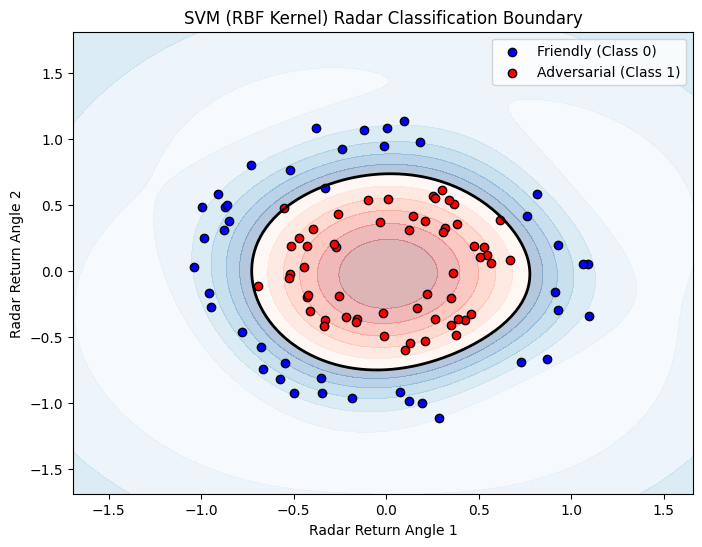

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. Generate Non-Linear Radar Data (Concentric circles representing flight envelopes)
X_radar, y_radar = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)

df_radar = pd.DataFrame(X_radar, columns=['Radar_Return_Angle_1', 'Radar_Return_Angle_2'])
df_radar['Target_Class'] = y_radar # 0: Friendly, 1: Adversarial
print("Sample Radar Cross-Section Data:")
print(df_radar.head(), "\n")

# Split the data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_radar, y_radar, test_size=0.2, random_state=42)

# 2. Train SVM with RBF (Radial Basis Function) Kernel
svm = SVC(kernel='rbf', C=1.0)
svm.fit(X_train_r, y_train_r)

print("SVM Classification Report:")
print(classification_report(y_test_r, svm.predict(X_test_r)))

# 3. Plot the Non-Linear Decision Boundary
xx, yy = np.meshgrid(np.linspace(X_radar[:,0].min()-0.5, X_radar[:,0].max()+0.5, 100),
                     np.linspace(X_radar[:,1].min()-0.5, X_radar[:,1].max()+0.5, 100))
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap='Blues', alpha=0.3) # Friendly Zone
plt.contourf(xx, yy, Z, levels=np.linspace(0, Z.max(), 7), cmap='Reds', alpha=0.3) # Adversarial Zone
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black') # Decision Boundary

# Scatter the test data
plt.scatter(X_test_r[y_test_r == 0, 0], X_test_r[y_test_r == 0, 1], color='blue', label='Friendly (Class 0)', edgecolors='k')
plt.scatter(X_test_r[y_test_r == 1, 0], X_test_r[y_test_r == 1, 1], color='red', label='Adversarial (Class 1)', edgecolors='k')

plt.title('SVM (RBF Kernel) Radar Classification Boundary')
plt.xlabel('Radar Return Angle 1')
plt.ylabel('Radar Return Angle 2')
plt.legend()
plt.show()


### Interpreting the Results

The make_circles dataset simulates a scenario where adversarial radar returns (red dots) are nested tightly inside the flight envelope of friendly returns (blue dots)—a highly non-linear problem.

The plot visually demonstrates the power of the **Kernel Trick**. A simple linear classifier like Logistic Regression would attempt to draw a straight line through this data, failing catastrophically. The SVM, using an RBF kernel, correctly wraps a circular decision boundary (the solid black line) completely around the adversarial flight envelope, separating the donut hole from the outer ring. High precision and recall in this context mean fewer friendly-fire incidents and higher threat interception.